# Detection

In [109]:
import torch
from torch import Tensor
import numpy as np
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from pathlib import Path
import torch
from torch import nn, optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader, Dataset
from datetime import datetime
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import torch.nn.functional as F
from collections import Counter
import json
from itertools import product
import math
import hashlib
import io
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib import patches

### Setup

In [110]:
SEED = 265
torch.manual_seed(SEED)
torch.set_default_dtype(torch.float32)

In [111]:
IMG_HEIGHT, IMG_WIDTH = 48, 60
DATA_DIR = Path("data")
BATCH_SIZE = 32

In [112]:
EPOCH_INVESTIGATE_POINTS = [2,4,6,10,12,15]
MAX_EPOCHS = 15

In [113]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Training on device {device}.")

Training on device cpu.


In [114]:
DO_TRAINING = True  # Set me to TRUE to run training from the start, otherwise we just load existing models

In [115]:
save_dir = Path("imgs/object_detection")
save_dir.mkdir(parents=True, exist_ok=True)

## Pre-existing code

In [116]:
def get_map_results(model, eval_loader):
    '''
        Helper functions to get predictions and targets in the format required for mAP calculation.
        Depending on your data processing and model architecture this function can either be used as is, 
        modified to fit your needs or used as a blue print for a rewrite.
        Here it is assussmed that the image has been divide into a 2 x 3 grid.
        ----------------------------------------------------------
        Run through the data in the dataloader and collect predicitions and targets for mAP calculation.

        torchmetric mAP expects predictions and targets in the format:
        preds = [
           { "boxes": tensor([[x1, y1, x2, y2], ...]), "scores": tensor([score1, score2, ...]), "labels": tensor([label1, label2, ...])},
            ...   ]
        and targets = [
            { "boxes": tensor([[x1, y1, x2, y2], ...]), "labels": tensor([label1, label2, ...])},
            ...   ]
        where each dict in the list corresponds to one image in the dataset and contains the predicted and true results
    '''
    model.eval()
    with torch.no_grad():
        preds = []
        targets = []
        for images, labels in eval_loader:

            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            outputs = outputs.permute(0, 2, 3, 1)                               # (B, 7, 2, 3) → (B, 2, 3, 7)
            outputs = outputs.reshape(outputs.shape[0], -1, outputs.shape[-1])  # (B, 2, 3, 7) → (B, 6, 7)
            labels = labels.reshape(labels.shape[0], -1, labels.shape[-1])      # (B, 2, 3, 6) → (B, 6, 6)

            for output, label in zip(outputs, labels):
                pred_boxes = []
                pred_scores = []
                pred_labels = []
                target_boxes = []
                target_labels = []
                # collect predicted boxes, scores and labels for the current image
                for i, cell_output in enumerate(output):
                    pred_object_presence = (torch.sigmoid(cell_output[0]) > 0.5) * 1.0
                    if pred_object_presence == 1:
                        # get propability of object presence and class probabilities to compute detection score for mAP calculation
                        obj_prop = torch.sigmoid(cell_output[0]).item()
                        class_prop = F.softmax(cell_output[5:], dim=0)
                        pred_label = torch.argmax(class_prop)
                        detect_score = obj_prop * class_prop[pred_label]
                        # convert from local to global coordinates before we can compare with the labels and compute IoU for mAP calculation
                        bbox_global = local_to_global(i // 3, i % 3, cell_output[1:5])
                        bbox_xyxy = xywh_to_xyxy(bbox_global)
                        bbox_xyxy = torch.stack(bbox_xyxy)
                        # collect predicted boxes, scores and labels for the current image
                        pred_boxes.append(bbox_xyxy)
                        pred_scores.append(detect_score)
                        pred_labels.append(pred_label)
                # collect true boxes and labels for the current image
                for i, cell_label in enumerate(label):
                    true_object_presence = cell_label[0]
                    if true_object_presence == 1:
                        bbox_global = local_to_global(i // 3, i % 3, cell_label[1:5])
                        bbox_xyxy = xywh_to_xyxy(bbox_global)
                        bbox_xyxy = torch.stack(bbox_xyxy)
                        target_boxes.append(bbox_xyxy)
                        target_labels.append(int(cell_label[-1]))
                # store predictions and targets for the current image in the format required for mAP calculation
                # if there are no predicted boxes, we need to create an empty tensor for the boxes, scores and labels to avoid errors in the mAP calculation
                if len(pred_boxes) == 0:
                    pred_dict = {
                        "boxes": torch.zeros((0, 4), device=device),
                        "scores": torch.zeros((0,), device=device),
                        "labels": torch.zeros((0,), dtype=torch.long, device=device),
                    }
                    preds.append(pred_dict)
                else:
                    pred_dict = {
                        "boxes": torch.stack(pred_boxes),
                        "scores": torch.tensor(pred_scores, device=device),
                        "labels": torch.tensor(pred_labels, device=device),
                    }
                    preds.append(pred_dict)
                # if there are no true boxes, we need to create an empty tensor for the boxes and labels to avoid errors in the mAP calculation            
                if len(target_boxes) == 0:
                    target_dict = {
                        "boxes": torch.zeros((0, 4), device=device),
                        "labels": torch.zeros((0,), dtype=torch.long, device=device),
                    }
                    targets.append(target_dict)
                else:
                    target_dict = {
                        "boxes": torch.stack(target_boxes),
                        "labels": torch.tensor(target_labels, device=device),
                    }
                    targets.append(target_dict)
    
    # compute mAP using torchmetrics
    metric = MeanAveragePrecision(iou_type="bbox")
    metric.update(preds, targets)
    results = metric.compute()
    # results is a dict with the mAP results for different IoU thresholds and the overall mAP
    return results        

def local_to_global(i, j, bb, width=60, height=48, cols=3, rows=2):
    x, y, w, h = bb
    # get the dimensions of a single grid cell
    cell_width, cell_height = width / cols, height / rows
    # convert from local to global coordinates
    global_x = x * cell_width + j * cell_width
    global_y = y * cell_height + i * cell_height
    global_w = w * cell_width
    global_h = h * cell_height

    return global_x, global_y, global_w, global_h



In [117]:
def xywh_to_xyxy(bb):
    # convert from center format to box format
    x_center, y_center, w, h = bb
    x1 = x_center - w/2
    y1 = y_center - h/2
    x2 = x_center + w/2
    y2 = y_center + h/2
    return x1, y1, x2, y2   

def compute_rmse_arrs(actual_bb, pred_bb):
    return np.sqrt(np.mean((actual_bb - pred_bb) ** 2))

def compute_map(model, loader):
    """
    Based on existing code
    """
    model.eval()
    preds = []
    targets = []
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            
            for output, label in zip(outputs, labels):
                z_pred = torch.sigmoid(output[0])
                
                if z_pred > 0.5:
                    bbox = xywh_to_xyxy(output[1:5])
                    pred_label = output[5:].argmax()
                    preds.append({
                        "boxes": torch.stack(bbox).unsqueeze(0),
                        "scores": torch.tensor([z_pred]),
                        "labels": torch.tensor([pred_label]),
                    })
                else:
                    preds.append({
                        "boxes": torch.zeros((0, 4), device=device),
                        "scores": torch.zeros((0,), device=device),
                        "labels": torch.zeros((0,), dtype=torch.long, device=device),
                    })
                
                if label[0] == 1:
                    bbox = xywh_to_xyxy(label[1:5])
                    targets.append({
                        "boxes": torch.stack(bbox).unsqueeze(0),
                        "labels": torch.tensor([label[5].long()]),
                    })
                else:
                    targets.append({
                        "boxes": torch.zeros((0, 4), device=device),
                        "labels": torch.zeros((0,), dtype=torch.long, device=device),
                    })
    
    metric = MeanAveragePrecision(iou_type="bbox")
    metric.update(preds, targets)
    return metric.compute()["map"].item()

### Load data and preprocessing

In [118]:
dataset_train = torch.load(DATA_DIR / f"localization_train.pt", weights_only = False)
dataset_val = torch.load(DATA_DIR / f"localization_val.pt", weights_only = False)
dataset_test = torch.load(DATA_DIR / f"localization_test.pt", weights_only = False)

train_loader = DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(dataset_val, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(dataset_test, batch_size=BATCH_SIZE, shuffle=False)

In [119]:
print(len(dataset_train))
# Looks like a good amount of data

59400


In [120]:
dataset_train[1]

(tensor([[[0.0675, 0.0680, 0.1299,  ..., 0.1490, 0.1387, 0.4211],
          [0.2859, 0.2007, 0.2737,  ..., 0.0675, 0.2135, 0.2742],
          [0.1441, 0.6017, 0.1573,  ..., 0.1432, 0.2245, 0.0843],
          ...,
          [0.5310, 0.4511, 0.5308,  ..., 0.4070, 0.1443, 0.3776],
          [0.3209, 0.3970, 0.4780,  ..., 0.4493, 0.4522, 0.2817],
          [0.3668, 0.4166, 0.3739,  ..., 0.5149, 0.2977, 0.3304]]]),
 tensor([1.0000, 0.2167, 0.6250, 0.3000, 0.5000, 0.0000]))

Looks ok, but seems like the image bounding box coords have also been scaled, lets take that into account when plotting

In [121]:
def plot_image(img_tensor, ax):
    # if ax is None:
        # make own ax
    img_pixels = img_tensor[0]
    is_item, x, y, h, w, class_label = img_tensor[1]

    img = img_pixels.permute(1, 2, 0)

    # since imgs are normalized we should scale them first
    scaled_x = x*IMG_WIDTH
    scaled_w = w*IMG_WIDTH

    scaled_y = y*IMG_HEIGHT
    scaled_h = h*IMG_HEIGHT

    scaled_x = scaled_x - scaled_w / 2
    scaled_y = scaled_y - scaled_h / 2

    ax.imshow(img)
    ax.add_patch(
        patches.Rectangle((scaled_x, scaled_y), scaled_w, scaled_h, linewidth=5, edgecolor='r', facecolor='none')
    )
    
    ax.set_title(f"Image with class {int(class_label)}, is item = {int(is_item)}")
    return ax

def plot_image_with_prediction(img_tensor, ax, predicted_box: list):
    """
    predicted box = [x,y,w,h]
    """
    # if ax is None:
        # make own ax
    img_pixels = img_tensor[0]
    is_item, x, y, h, w, class_label = img_tensor[1]

    img = img_pixels.permute(1, 2, 0)

    # since imgs are normalized we should scale them first
    scaled_x = x*IMG_WIDTH
    scaled_w = w*IMG_WIDTH

    scaled_y = y*IMG_HEIGHT
    scaled_h = h*IMG_HEIGHT

    scaled_x = scaled_x - scaled_w / 2
    scaled_y = scaled_y - scaled_h / 2

    ax.imshow(img)
    ax.add_patch(
        patches.Rectangle((scaled_x, scaled_y), scaled_w, scaled_h, linewidth=5, edgecolor='r', facecolor='none')
    )

    pred_x, pred_y, pred_w, pred_h = predicted_box

    ax.add_patch(
        patches.Rectangle((pred_x, pred_y), pred_w, pred_h, linewidth=5, edgecolor='y', facecolor='none')
    )

    ax.legend(
        ["red", "yellow"],
        ["actual", "predicted"]
    )
    
    ax.set_title(f"Image with class {int(class_label)}, is item = {int(is_item)}")
    return ax

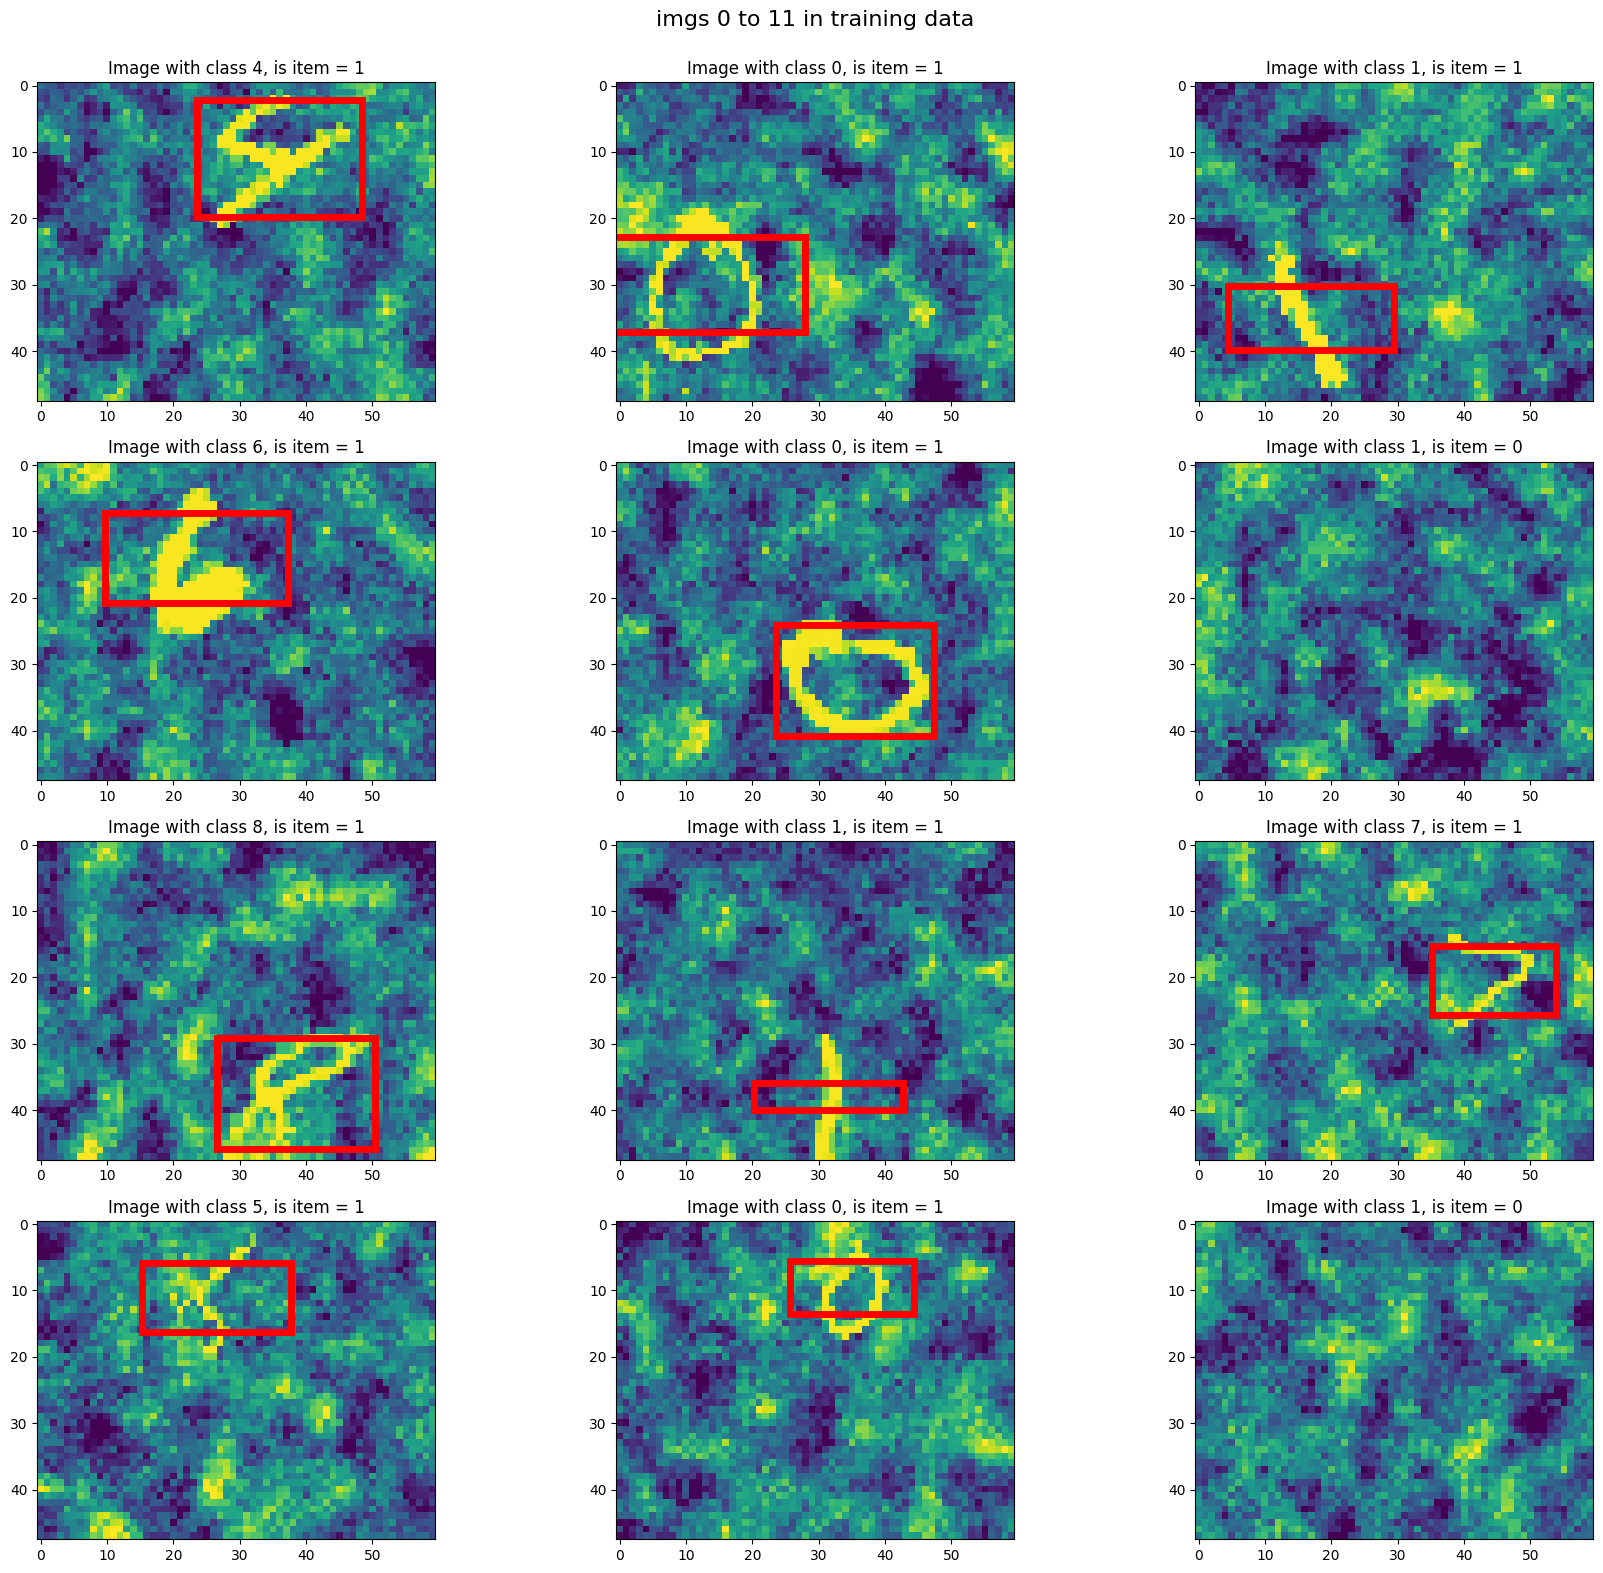

In [122]:
def plot_multiple(indicies: list, title: str, dataset):
    n = len(indicies)
    cols = 3
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
    axes = axes.flatten() if n > 1 else [axes]

    fig.suptitle(f"{title}", fontsize=16)

    for ax, index in zip(axes, indicies):
        plot_image(dataset[index], ax)

    for i in range(n, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    # fig.savefig(save_dir / f"hyperparams_{model_title}.png", dpi=500)

    plt.show()

plot_multiple(
    [i for i in range(12)],
    "imgs 0 to 11 in training data",
    dataset_train
)

Ok looks good! Some of the bounding boxes are a little strange, but they should still work.

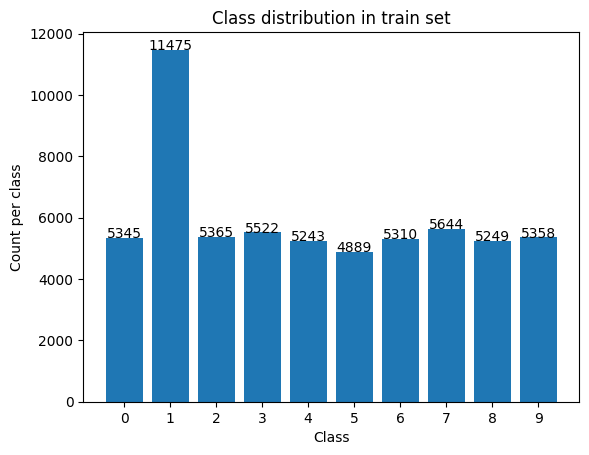

In [123]:
all_targets = torch.tensor(
    [label[1][5] for label in dataset_train]
).tolist()

counts = Counter(all_targets)
plt.bar(
    list(counts.keys()), list(counts.values()), label=counts.keys()
)
plt.xlabel("Class")
plt.ylabel("Count per class")
plt.title("Class distribution in train set")
for x, y in counts.items():
    plt.text(x, y, f"{y}", ha="center")

plt.xticks([i for i in range(10)])
plt.savefig(save_dir / "class_dist.png")
plt.show()

Looks like there is some class imbalance! However i dont expect this to be a major major problem since most classes are equally balanced. I dont think the model can get away with getting very good at 1 and ignoring the rest of the classes.

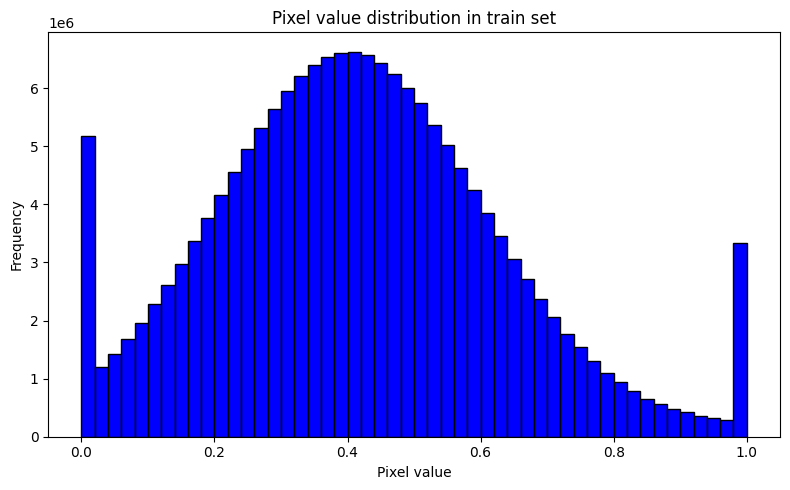

In [124]:

all_pixels = torch.cat([img_tensor[0].view(-1) for img_tensor in dataset_train])

plt.figure(figsize=(8,5))
plt.hist(all_pixels.numpy(), bins=50, color='blue', edgecolor='black')
plt.xlabel("Pixel value")
plt.ylabel("Frequency")
plt.title("Pixel value distribution in train set")
plt.tight_layout()
plt.savefig(save_dir / "pixel_dist.png")
plt.show()

Nice! Looks like a normal distribution, but peaks at 0 and 1.

# Training

In [125]:
logits_loss = nn.BCEWithLogitsLoss()
cross_entropy = nn.CrossEntropyLoss()
mse_loss = nn.MSELoss()

def ObjectDetectionLoss(pred, actual):
    """
    Loss function for a neural network with pred/actual vectors like:
    [
     z : is there an object in the image?
     x : coords
     y : coords
     w : coords
     h : coords
     c1 : class 1 probability
     c2
     c3
     ...
     c_n : class n probability
    ]
    """
    # grab all values
    z_actual, z_pred = actual[:, 0], pred[:, 0]
    class_actual, class_pred = actual[:, 5:], pred[:, 5:] 
    bb_actual, bb_pred = actual[:, 1:5], pred[:, 1:5]

    # see what case we are in
    
    is_object_mask = z_actual == 1

    # both branches do this
    total_loss = logits_loss(z_pred, z_actual) # -log(sigmoid(z)), yes/no loss

    if is_object_mask.any():
        total_loss += mse_loss(bb_pred[is_object_mask], bb_actual[is_object_mask]) # # rmse per bounding box coords
        total_loss += cross_entropy(class_pred[is_object_mask], class_actual[is_object_mask, 0].long()) # -log(softmax(z)), class loss

    return total_loss

In [126]:
def compute_IoU(cnn, loader: DataLoader) -> int:

    def intersection_union(pred, true):
        # based on: https://gist.github.com/markub3327/ecdba14f9e4f422098c33ac760557414
        x_pred, y_pred, w_pred, h_pred = pred[1], pred[2], pred[3], pred[4]
        x_true, y_true, w_true, h_true = true[1], true[2], true[3], true[4]

        rmost = max(x_pred, x_true) # rightmost
        lmost = min(w_pred, w_true) # leftmost

        tallest = max(y_pred, y_true) # tallest
        lowest = min(h_pred, h_true)  # lowest

        intersection = abs(max((lmost - rmost, 0)) * max((lowest - tallest), 0))

        box_pred_area = abs((h_pred - x_pred) * (w_pred - y_pred))
        box_true_area = abs((h_true - x_true) * (w_true - y_true))

        union = box_pred_area + box_true_area - intersection

        # # torchvision.ops.box_convert TODO

        assert (intersection <= union, "Intersection is larger than union!") # sanity check

        return union, intersection

    cnn.eval()
    total = 0
    count = 0

    with torch.no_grad():
        for img, label in loader:
            pred = cnn(img)
            union, intersection = intersection_union(pred, label)
            total += (intersection / union)
            count+=1

    return total / count


<>:23: SyntaxWarning: assertion is always true, perhaps remove parentheses?
<>:23: SyntaxWarning: assertion is always true, perhaps remove parentheses?
/tmp/ipykernel_463503/2950908541.py:23: SyntaxWarning: assertion is always true, perhaps remove parentheses?
  assert (intersection <= union, "Intersection is larger than union!") # sanity check


In [127]:
def train(
    n_epochs,
    optimizer,
    model,
    loss_fn,
    train_loader: DataLoader,
    validation_loader: DataLoader,
):
    n_batch_train = len(train_loader)
    n_batch_val = len(validation_loader)

    losses_train, losses_val = [], []
    train_iou, val_iou = {}, {}

    model.train()  # set to train mode
    optimizer.zero_grad(set_to_none=True)

    for epoch in range(1, n_epochs + 1):
        loss_train, loss_val = 0.0, 0.0
        for imgs, labels in train_loader:
            imgs = imgs.to(device=device, dtype=torch.float32)
            labels = labels.to(device=device)

            outputs = model(imgs)

            loss = loss_fn(outputs, labels)
            loss.backward()

            optimizer.step()
            optimizer.zero_grad()

            loss_train += loss.item()

        model.eval()  # observe model performance
        with torch.no_grad():
            for val_imgs, val_labels in validation_loader:
                imgs_val = val_imgs.to(device=device, dtype=torch.float32)
                val_labels = val_labels.to(device=device, dtype=torch.float32)
                val_outputs = model(imgs_val)
                val_loss = loss_fn(val_outputs, val_labels)
                loss_val += val_loss.item()

        if epoch in EPOCH_INVESTIGATE_POINTS:
            train_iou[epoch] =  compute_map(model, train_loader) # compute_IoU(model, train_loader)
            val_iou[epoch] = compute_map(model, val_loader) # compute_IoU(model, validation_loader)

        model.train()

        losses_train.append(loss_train / n_batch_train)
        losses_val.append(loss_val / n_batch_val)

        if epoch == 1 or epoch % 5 == 0:
            print(
                "{}  |  Epoch {}  |  Training loss {:.3f} Validation loss {:.3f}".format(
                    datetime.now().time(), epoch, loss_train / n_batch_train, loss_val / n_batch_val
                )
            )
    return losses_train, losses_val, train_iou, val_iou

In [128]:
class CNNBaseline(nn.Module):
    """
    todo descrpition
    """
    
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=16,
            kernel_size=3,
            stride=1,
            padding=1
        )
        self.pool1 = nn.MaxPool2d(
            kernel_size=2, 
            stride=2
        )
        self.conv2 = nn.Conv2d(
            in_channels=16,
            out_channels=32,
            kernel_size=3,
            stride=1,
            padding=1
        )
        self.pool2 = nn.MaxPool2d(
            kernel_size=2, 
            stride=2
        )
        self.conv3 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            stride=1,
            padding=1
        )
        self.pool3 = nn.MaxPool2d(
            kernel_size=2, 
            stride=2
        )
        self.fc1 = nn.Linear(2688, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 15)
        # no special output since we are using a custom loss function!

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.pool3(F.relu(self.conv3(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [129]:
class CNNDeep(nn.Module):
    """
    inp layer: conv2d
    hid layer: pool
    hid layer: conv2
    hid layer: conv2
    hid layer: fc1
    hid layer: fc2
    hid layer: fc3

    out layer: 32 - 2 no activation function
    """
        
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 15)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [130]:
class CNNPadding(nn.Module):
    """
    inp layer: conv2d
    hid layer: pool
    hid layer: conv2
    hid layer: conv2
    hid layer: fc1
    hid layer: fc2
    hid layer: fc3

    out layer: 32 - 2 no activation function
    """
    # todo add padding
    
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(48 * 60, 6, 2)
        self.pool = nn.MaxPool2d(2, 2) # turn 48*60 to 24*30
        # self.conv2 = nn.Conv2d(6, 16, 5)
        # self.fc1 = nn.Linear(16 * 5 * 5, 120)
        # self.fc2 = nn.Linear(120, 84)
        # self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [131]:
def make_model_hash(model, params):
    """Code partially generated by ChatGPT"""
    buffer = io.BytesIO()
    torch.save(model.state_dict(), buffer)
    buffer.seek(0)
    model_bytes = buffer.read()
    param_bytes = str(sorted(params.items())).encode()
    combined = model_bytes + param_bytes
    return hashlib.sha256(combined).hexdigest()[:10]

In [132]:
class ModelOutcome:
    def __init__(
        self,
        train_losses: list,
        val_losses: list,
        params: dict,
        train_iou: list[float],
        val_iou: list[float],
        model_path: Path,
    ):
        self.train_losses = train_losses
        self.val_losses = val_losses

        self.params = params

        self.train_iou = train_iou
        self.val_iou = val_iou

        self.model_path = model_path

    def to_dict(self) -> dict:
        return {
            "train_losses": self.train_losses,
            "val_losses": self.val_losses,
            "params": self.params,
            "train_iou": self.train_iou,
            "val_iou": self.val_iou,
            "model_path": str(self.model_path) if self.model_path else None,
        }

    @staticmethod
    def from_dict(d: dict):
        return ModelOutcome(
            train_losses=d["train_losses"],
            val_losses=d["val_losses"],
            params=d["params"],
            train_iou={int(k): v for k, v in d["train_iou"].items()},
            val_iou={int(k): v for k, v in d["val_iou"].items()},
            model_path=Path(d["model_path"]) if d.get("model_path") else None,
        )

In [133]:
object_detection_loss = ObjectDetectionLoss

In [134]:
def plot_train_val_losses(
    train_losses,
    val_losses,
    train_acc,
    val_acc,
    params: dict = None,
    ax=None,
    title=None,
):
    """Code partially generated by ChatGPT"""
    if ax is None:
        _fig, ax = plt.subplots(figsize=(8, 5))

    epochs = range(1, len(train_losses) + 1)

    ax.plot(epochs, train_losses, label="train loss")
    ax.plot(epochs, val_losses, label="val loss")

    if title:
        ax.set_title(title)

    y_max = max(max(train_losses), max(val_losses))
    y_offset = 0.05 * y_max  # small offset above curves

    for epoch in EPOCH_INVESTIGATE_POINTS:
        if epoch - 1 < len(train_losses):  # check bounds
            train_acc_text = train_acc[epoch]
            val_acc_text = val_acc[epoch]

            # vertical line
            ax.axvline(x=epoch, color="gray", linestyle="--", alpha=0.5)

            # text above the curves
            ax.text(
                epoch - 1,
                y_max + y_offset,
                f"Val acc: {val_acc_text:.3f}",
                color="orange",
                fontsize=9,
                ha="center",
                va="bottom",
            )
            ax.text(
                epoch - 1,
                y_max + 2 * y_offset,
                f"Train acc: {train_acc_text:.3f}",
                color="blue",
                fontsize=9,
                ha="center",
                va="bottom",
            )

    # https://matplotlib.org/stable/gallery/text_labels_and_annotations/placing_text_boxes.html
    if params:
        param_text = "\n".join([f"{key} : {value}" for key, value in params.items()])
        props = dict(boxstyle="round", facecolor="wheat", alpha=0.5)
        ax.text(
            x=0.05,
            y=0.05,
            s=param_text,
            transform=ax.transAxes,
            verticalalignment="bottom",
            bbox=props,
        )

    ax.legend()
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    return ax

In [135]:
model_baseline = CNNBaseline().to(device)

In [ ]:
if DO_TRAINING:
    object_detection_optimizer = optim.Adam(model_baseline.parameters())

    train_losses, validation_losses, train_accuracies_base, val_accuracies_base = train(
        n_epochs=MAX_EPOCHS,
        optimizer=object_detection_optimizer,
        model=model_baseline,
        loss_fn=object_detection_loss,
        train_loader=train_loader,
        validation_loader=val_loader,
    )

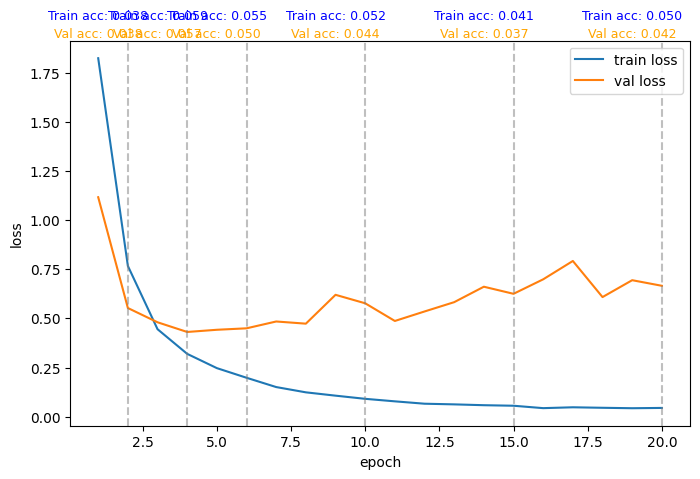

In [ ]:
if DO_TRAINING:
    baseline_plot = plot_train_val_losses(
        train_losses=train_losses,
        val_losses=validation_losses,
        train_acc=train_accuracies_base,
        val_acc=val_accuracies_base,
        params={},
    )
    baseline_plot

In [ ]:
padding = [0,1]
stride = [1,2,3]
hidden_layer_complexity = []

In [ ]:
all_model_outcomes: dict[list[ModelOutcome]] = {}
if DO_TRAINING:
    models_dir = Path("models")
    models_dir.mkdir(exist_ok=True)

    for model_class in models:
        params_and_losses: list[ModelOutcome] = []

        perms = product(learning_rate_ls, momentum_ls, weight_decay_ls)
        model_count = (
            len(learning_rate_ls) * len(momentum_ls) * len(weight_decay_ls)
        )

        for index, hyperparams in enumerate(perms):
            torch.manual_seed(SEED)
  
            learning_rate, momentum, weight_decay = hyperparams
            model = model_class().to(device)

            optimizer = optim.Adam(
                model.parameters(),
                lr=learning_rate,
                weight_decay=weight_decay,   
            )

            train_losses, validation_losses, train_accuracies, val_accuracies = train(
                n_epochs=MAX_EPOCHS,
                optimizer=optimizer,
                model=model,
                loss_fn=object_detection_loss,
                train_loader=train_loader,
                validation_loader=val_loader,
            )
            print(f"Trained {index} of {model_count} model permuations")

            params = {
                "model": model.name(),
                "learning_rate": learning_rate,
                "momentum": momentum,
                "weight_decay": weight_decay,
            }

            model_hash = make_model_hash(model, params)
            model_path = models_dir / f"{model_hash}.pt"

            torch.save(model.state_dict(), model_path)

            model_outcome = ModelOutcome(
                train_losses=train_losses,
                val_losses=validation_losses,
                params=params,
                train_accuracies=train_accuracies,
                validation_accuracies=val_accuracies,
                model_path=model_path,
            )

            params_and_losses.append(model_outcome)

        print(f"Finished training {model.name()}")
        all_model_outcomes[model.name()] = params_and_losses

    all_model_outcomes.keys()

NameError: name 'models' is not defined

### Prediction

In [ ]:
def grab_predictions(model, dataset):
    all_preds = []
    all_actual = []
    
    with torch.no_grad():
        for imgs, actual_vector in dataset:
            imgs = imgs.to(device, dtype=torch.float32)
            actual_vector = actual_vector.to(device)
            
            pred_vector = model(imgs)
            
            all_preds.append(pred_vector.cpu())
            all_actual.append(actual_vector.cpu())
    
    return torch.cat(all_preds, dim=0), torch.cat(all_actual, dim=0)

In [ ]:
def confusion_matrix_custom(actual, pred, title, type: str):
    # fix display labels must match!
    """Code partially generated by ChatGPT"""
    
    cm = confusion_matrix(actual, pred)
    cm_percent = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100
    cm_percent = np.nan_to_num(cm_percent)

    _fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # all
    disp1 = ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=[i for i in range(10)]
    )
    disp1.plot(ax=axes[0], cmap=plt.cm.Blues, colorbar=False)
    axes[0].set_title(f"Counts: {title}")

    # percentages
    disp2 = ConfusionMatrixDisplay(
        confusion_matrix=cm_percent, display_labels=[i for i in range(10)]
    )
    disp2.plot(ax=axes[1], cmap=plt.cm.Blues, colorbar=True, values_format=".1f")
    axes[1].set_title(f"Percentages: {title}")

    plt.tight_layout()
    plt.savefig(save_dir / f"{title}_{type}.png")
    plt.show()

In [ ]:
def get_rmse_bounding_boxes_per_class(all_preds, all_actual, all_actual_labels, set_label):
    rmse_dict = {}

    labels_int = all_actual[:, 5].long().numpy()

    for cls in range(0,10):
        indexes = np.where(labels_int == cls)
        print(cls, len(all_actual[indexes])) # 0,0
        rmse_dict[cls] = compute_rmse_arrs(all_actual[indexes], all_preds[indexes])

    plt.bar(
        list(rmse_dict.keys()), list(rmse_dict.values()), label=rmse_dict.keys()
    )

    plt.xlabel("Class")
    plt.ylabel("Bounding box RMSE")
    plt.title(f"Bounding box RMSE per class distribution in {set_label} set")
    for x, y in rmse_dict.items():
        plt.text(x, y, f"{y}", ha="center")

    plt.xticks([i for i in range(10)])
    plt.savefig(save_dir / f"bb_rmse_{set_label}.png")
    plt.show()

In [ ]:
all_preds, all_actual = grab_predictions(model_baseline, train_loader) # swap me to best!

In [ ]:
all_actual[0]

tensor([1.0000, 0.6000, 0.2292, 0.3667, 0.4167, 4.0000])

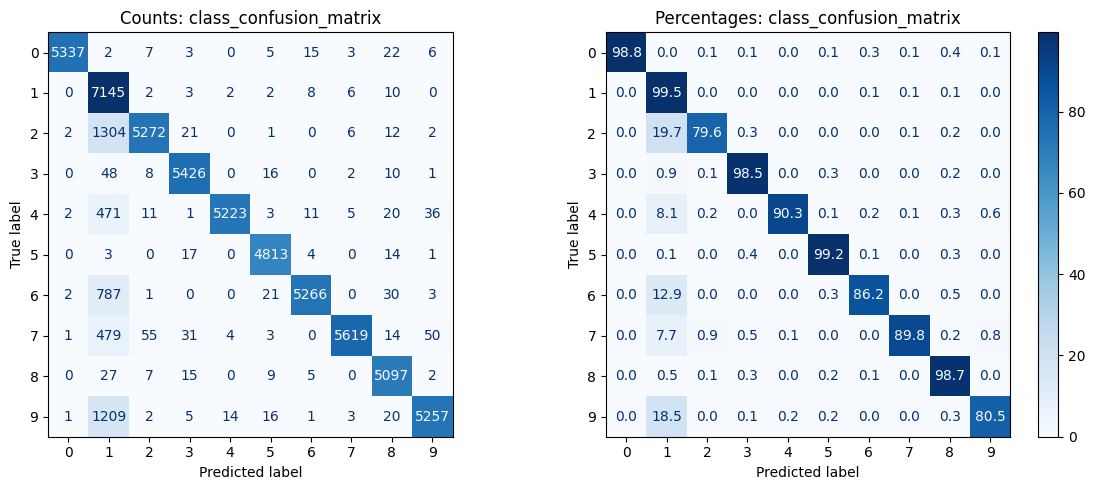

In [ ]:
# accuracy class
pred_labels = all_preds[:, 5:].argmax(dim=1)
actual_labels = all_actual[:, 5].long()

confusion_matrix_custom(pred_labels.numpy(), actual_labels.numpy(), "class_confusion_matrix", "train")

ValueError: The number of FixedLocator locations (2), usually from a call to set_ticks, does not match the number of labels (10).

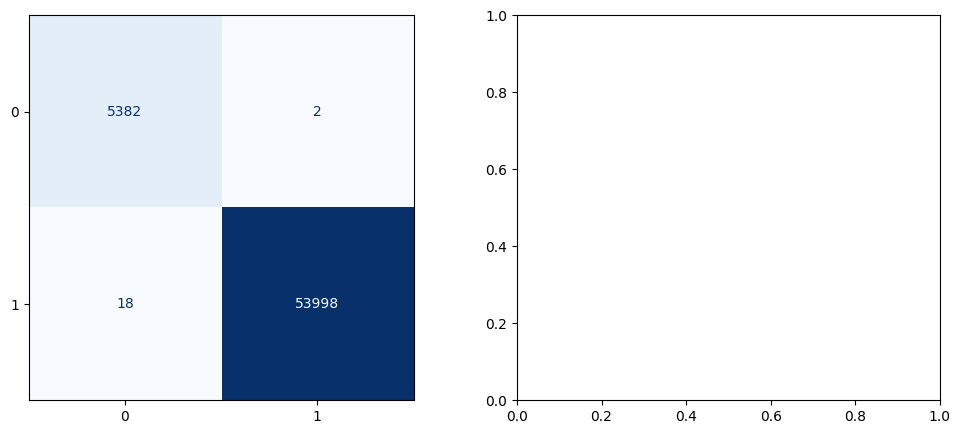

In [ ]:
# accuracy object
pred_object = (torch.sigmoid(all_preds[:, 0]) > 0.5).long()
actual_object = all_actual[:, 0].long()

confusion_matrix_custom(
    pred_object.numpy(), actual_object.numpy(), "object_confusion_matrix", "train"
)

In [ ]:
# accuracy bounding boxes
pred_bb = all_preds[:, 1:5]
actual_bb = all_actual[:, 1:5]
all_actual_labels = all_actual[: 5]
get_rmse_bounding_boxes_per_class(pred_bb.numpy(), actual_bb.numpy(), all_actual_labels.numpy(), "train")

TypeError: only 0-dimensional arrays can be converted to Python scalars

### Model selection and evaluation

In [ ]:
# TODO